In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import geopandas as gpd
import contextily as ctx
from shapely.geometry import Point
from mpl_toolkits.mplot3d import Axes3D
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PolynomialFeatures
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from mpl_toolkits.mplot3d import Axes3D
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import GradientBoostingRegressor
from features_maker import NearestCityTransformer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from utilities import cross_val_price_metrics_from_log

from utilities import *
import features_maker

# Projet prédiction de loyer
### Raphaël Thieffry, Antonin Russac, Ethan Puyaubreau

---

### Récupération des données
Nous avons récupérés les données des locations d'appartements en France à l'aide de l'API de [Bien'ici](https://www.bienici.com/), qui est un agrégateur d'annonces immobilières.  
Nous avons ainsi récupéré un CSV de plus de 2000 annonces. Ceci en est un petit aperçu :

In [ ]:
csv_file = "rents.csv"
df = pd.read_csv(csv_file)

df.head(3)

,id,reference,account_type,account_name,customer_id,city,postal_code,department_code,district_name,district_label,...,ad_created_by_pro,on_market,leading_ad,photos_count,virtual_tours_count,title,description,exposition,year_of_construction,transaction_type
0,ics-jol_JOLIS_M2_loc-GES00120002-876,GES00120002-876,agency,NaN,gilles-trignat-residence-1698152662756,Sassenage,38360,38,Sassenage,Sassenage,...,True,True,False,14,0,NaN,"Sassenage, rue Charles de Gaulle, secteur Oval...",Nord-est,2009.0,rent
1,ics-jol_JOLIS_M2_loc-GES00380002-876,GES00380002-876,agency,NaN,gilles-trignat-residence-1698152662756,Sassenage,38360,38,Sassenage,Sassenage,...,True,True,True,8,0,NaN,"studio avec jardin et parking - SASSENAGE, Sec...",Nord-est,2004.0,rent
2,ics-jol_JOLIS_M2_loc-GES00380003-876,GES00380003-876,agency,NaN,gilles-trignat-residence-1698152662756,Sassenage,38360,38,Sassenage,Sassenage,...,True,True,False,11,0,NaN,"SASSENAGE, secteur OVALIE. Dans une propriété ...",Est,NaN,rent


### Nettoyage des données
Dans l'objectif de déterminer les loyers, nous allons maintenant supprimer les features non-pertinentes dans la décision du loyer (par exemple : le nom de l'agence immobilière, l'id de l'annonce, ...)  
Le **prix** est bien sûr la variable cible sur laquelle nous voulons faire la régression.  
Il ne reste ainsi que 28 métriques :
| Localisation         | Surface & Pièces         | Équipements Intérieurs   | Équipements Extérieurs | Énergie & Coûts         |
|----------------------|--------------------------|--------------------------|------------------------|-------------------------|
| city                 | surface                  | elevator                 | balconies             | energy_class            |
| postal_code          | rooms                    | disabled_access          | terraces              | energy_value            |
| department_code      | bedrooms                 | furnished                | parking_places        | ghg_class                |
| lat                  | bathrooms                | duplex                   |                        | ghg_value                |
| lon                  | showers                  |                          |                        | energy_min_cost         |
| floor                |                          |                          |                        | energy_max_cost         |
|                      |                          |                          |                        | heating_type            |
|                      |                          |                          |                        | new_property             |
|                      |                          |                          |                        | description             |


In [3]:
pertinent_features = ["city", "postal_code", "department_code", "lat", "lon", "surface", "rooms", "bedrooms", "bathrooms", "showers", "floor", "balconies", "terraces", "parking_places", "cellars", "elevator", "disabled_access","furnished", "duplex", "energy_class", "energy_value", "ghg_class", "ghg_value", "energy_min_cost", "energy_max_cost","heating_type", "new_property", "description"] # columns for x
target_features = ["price"]
real_columns = ["price", "lat", "lon", "surface", "rooms", "bedrooms", "bathrooms", "showers", "floor", "balconies", "terraces", "parking_places", "cellars", "energy_value", "ghg_value", "energy_min_cost", "energy_max_cost"]

In [4]:
#prices = df[target_features].copy()
df = df[pertinent_features+target_features].copy()

# Counts NaN on each columns
df.isna().sum()

city                  0
postal_code           0
department_code       0
lat                   0
lon                   0
surface               2
rooms                 1
bedrooms             42
bathrooms           174
showers             125
floor                74
balconies           297
terraces            299
parking_places      275
cellars             332
elevator             75
disabled_access     246
furnished            42
duplex             1934
energy_class          0
energy_value         96
ghg_class             4
ghg_value            99
energy_min_cost     252
energy_max_cost     252
heating_type        109
new_property          0
description           0
price                 0
dtype: int64

### Suppression des lignes avec des champs "NaN" et préparation des données

In [5]:
df.loc[df["duplex"].isna(), "duplex"] = False # tout ceux dont le duplex est pas renseigné c'est que c'en est pas

In [6]:
df.notna().all(axis=1).sum() # les colonnes sans champ NaN <=> champs utilisables
df = df.dropna().copy()

In [7]:
df.shape # 28 features + la variable cible

(1452, 29)

#### On remarque que près du quart des données ont été retirées

### Visualisation des données (1)
Mise en relation de la variable cible avec les différentes features (numériques).

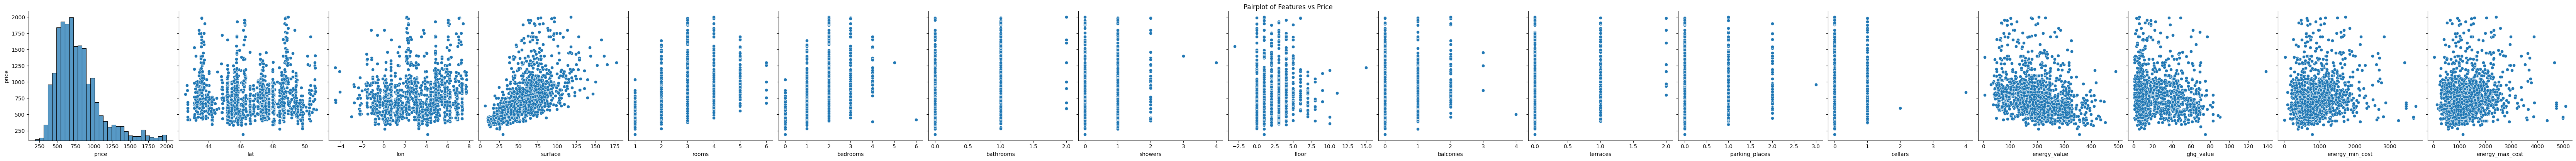

In [8]:
# Select the relevant columns
pairplot_data = df[real_columns]

# Generate the pairplot
sns.pairplot(pairplot_data, x_vars=real_columns, y_vars=["price"], height=4, aspect=1, kind="scatter")
plt.suptitle("Pairplot of Features vs Price", y=1.02)
plt.show()

### Visualisation des données (2)
Mise en relation de la valeur cible (Axe vertical) avec les données géographiques.

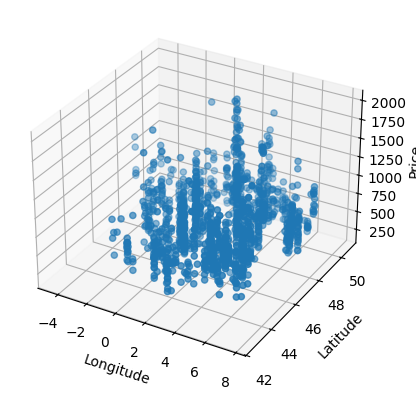

In [9]:
map3DFrance(df)

### Visualisation des données (3)
Superposition de la carte de France pour une meilleur visualisation. Les loyers sont en couleurs.

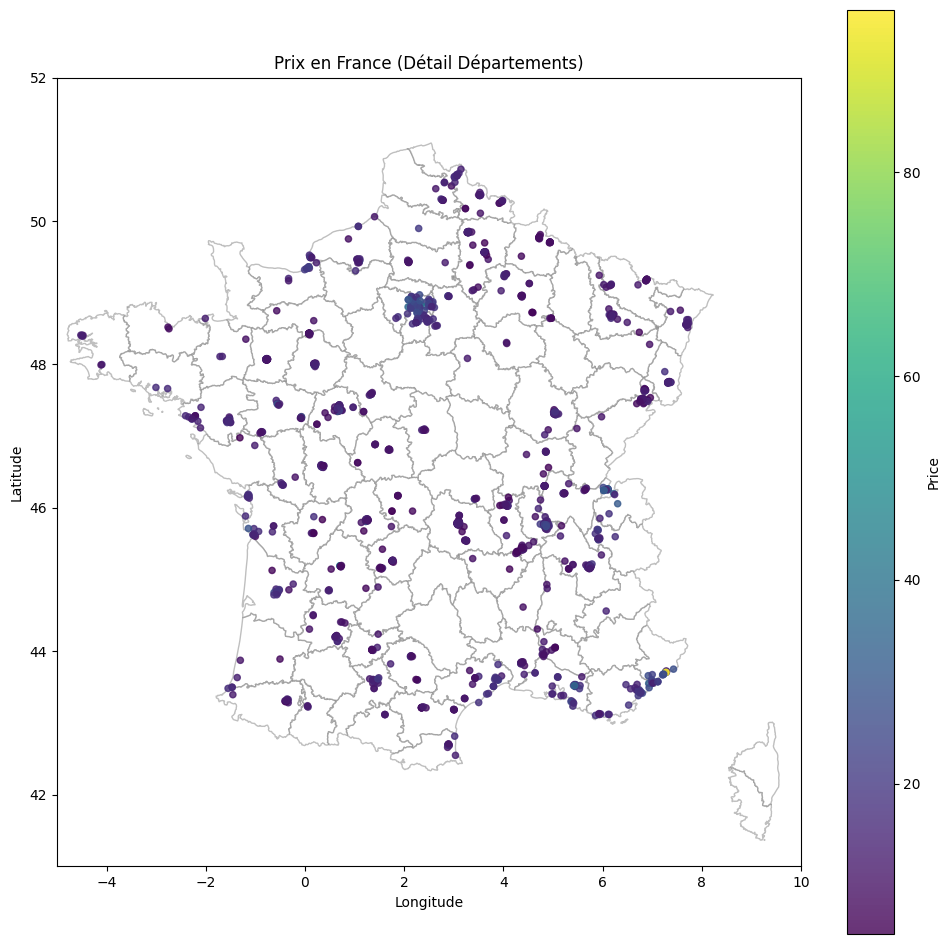

In [10]:
map2DFrance(df)

### Visualisation des données (4)
Focus sur la région parisienne.

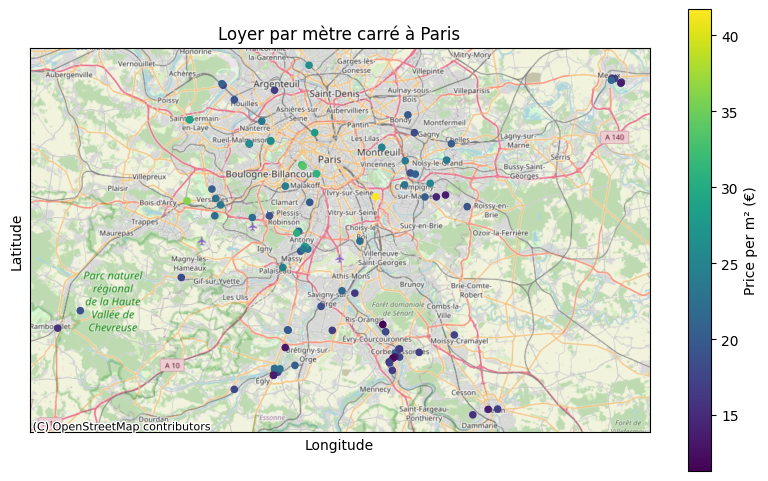

In [11]:
map2DParis(df)

### Premiers essais
Première approche naïve, en s'appuyant uniquement sur les données géographiques (longitude et latitude), avec un modèle de régression linéaire.

Mean Squared Error: 102850.57635436463
R² Score: 0.003165839247196933


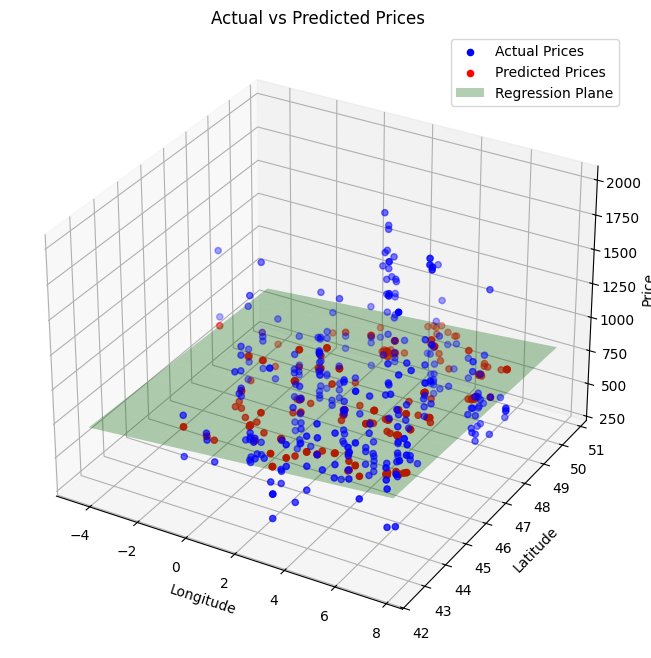

In [12]:
# Prepare data
X = df[["lon", "lat"]] ; y = df["price"]
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Train model
model = LinearRegression() ; model.fit(X_train, y_train)
# Predictions
y_pred = model.predict(X_test)
# Metrics
mse = mean_squared_error(y_test, y_pred) ; r2 = r2_score(y_test, y_pred) ; print(f"Mean Squared Error: {mse}\nR² Score: {r2}")
# Visualize predictions vs actual in 3D
fig = plt.figure(figsize=(10, 8)) ; ax = fig.add_subplot(111, projection='3d') ; ax.scatter(X_test["lon"], X_test["lat"], y_test, c='b', label='Actual Prices')
ax.scatter(X_test["lon"], X_test["lat"], y_pred, c='r', label='Predicted Prices') ; # Add the regression plane
lon_range = np.linspace(X["lon"].min(), X["lon"].max(), 10) ; lat_range = np.linspace(X["lat"].min(), X["lat"].max(), 10)
lon_grid, lat_grid = np.meshgrid(lon_range, lat_range) ; price_grid = model.intercept_ + model.coef_[0] * lon_grid + model.coef_[1] * lat_grid
ax.plot_surface(lon_grid, lat_grid, price_grid, alpha=0.3, color='green', label='Regression Plane') ; ax.set_xlabel('Longitude') ; ax.set_ylabel('Latitude') ; ax.set_zlabel('Price')
ax.set_title('Actual vs Predicted Prices') ; ax.legend() ; plt.show()

### Premiers essais
Même chose, mais avec une régression polynomiale de degré 10.

Polynomial Regression (degree 10) - Mean Squared Error: 84544.06106189082
Polynomial Regression (degree 10) - R² Score: 0.18059372010813945


c:\Users\Kerboul\devel\machine_learning\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


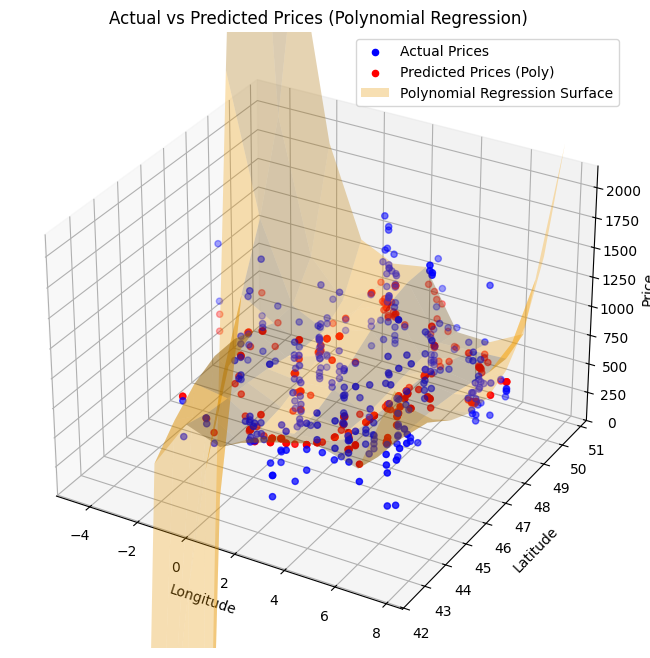

In [13]:
poly = PolynomialFeatures(degree=10) ; X_poly = poly.fit_transform(X)
X_train_poly, X_test_poly, y_train, y_test = train_test_split(X_poly, y, test_size=0.2, random_state=42)
model_poly = LinearRegression() ; model_poly.fit(X_train_poly, y_train)
y_pred_poly = model_poly.predict(X_test_poly) ; mse_poly = mean_squared_error(y_test, y_pred_poly)
r2_poly = r2_score(y_test, y_pred_poly) ; print(f"Polynomial Regression (degree 10) - Mean Squared Error: {mse_poly}")
print(f"Polynomial Regression (degree 10) - R² Score: {r2_poly}") ; # Visualize polynomial regression predictions vs actual in 3D
fig = plt.figure(figsize=(10, 8)) ; ax = fig.add_subplot(111, projection='3d') ; ax.scatter(X_test["lon"], X_test["lat"], y_test, c='b', label='Actual Prices')
ax.scatter(X_test["lon"], X_test["lat"], y_pred_poly, c='r', label='Predicted Prices (Poly)')
# Add the polynomial regression surface
price_grid_poly = model_poly.predict(poly.transform(np.c_[lon_grid.ravel(), lat_grid.ravel()])).reshape(lon_grid.shape)
ax.plot_surface(lon_grid, lat_grid, price_grid_poly, alpha=0.3, color='orange', label='Polynomial Regression Surface')
ax.set_xlabel('Longitude') ; ax.set_ylabel('Latitude') ; ax.set_zlabel('Price') ; ax.set_zlim(0, np.max(y_test)*1.1)
ax.set_title('Actual vs Predicted Prices (Polynomial Regression)') ; ax.legend() ; plt.show()

### Premiers essais
Comparaison avec une régression linéaire sur l'ensemble des features numériques

Linear Regression with all features - Mean Squared Error: 67724.05202928712
Linear Regression with all features - R² Score: 0.3436142901640753


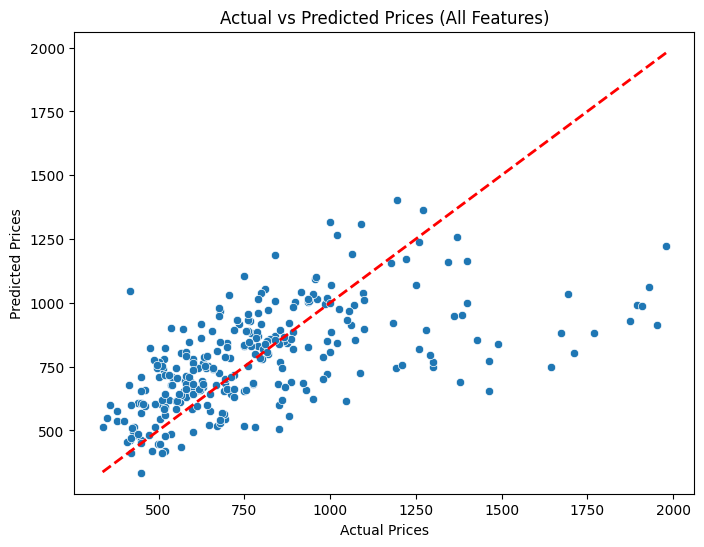

In [14]:
X_all = df[real_columns].drop(columns=["price"])
y_all = df["price"]
X_train_all, X_test_all, y_train_all, y_test_all = train_test_split(X_all, y_all, test_size=0.2, random_state=42)
model_all = LinearRegression()
model_all.fit(X_train_all, y_train_all)
y_pred_all = model_all.predict(X_test_all)
mse_all = mean_squared_error(y_test_all, y_pred_all)
r2_all = r2_score(y_test_all, y_pred_all)
print(f"Linear Regression with all features - Mean Squared Error: {mse_all}")
print(f"Linear Regression with all features - R² Score: {r2_all}")

# Plot predicted vs actual prices 
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test_all, y=y_pred_all)
plt.plot([y_test_all.min(), y_test_all.max()], [y_test_all.min(),
            y_test_all.max()], '--', lw=2, color='red')
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Prices (All Features)")
plt.show()

### Premier essais
Réduction de la dimensionalité avec PCA. Nouvel échec

PCA + Linear Regression - Mean Squared Error: 69944.16828801046
PCA + Linear Regression - R² Score: 0.322096785780696


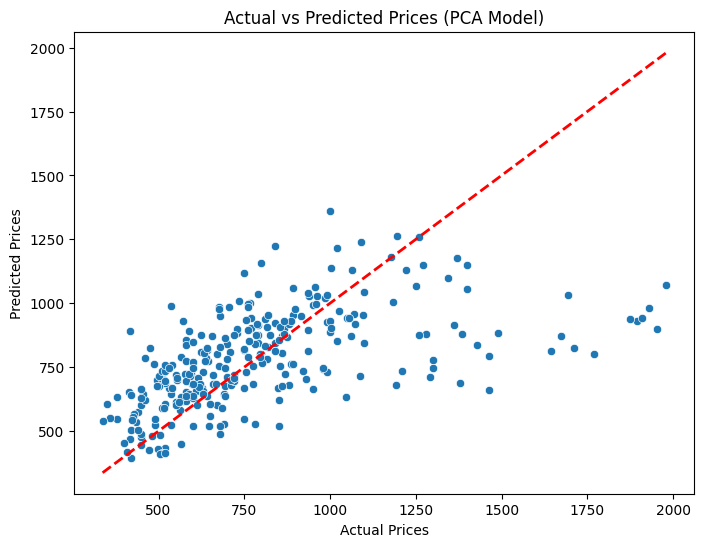

In [15]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_all)
pca = PCA(n_components=5) # reduce to 5 components

X_pca = pca.fit_transform(X_scaled)
X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(X_pca, y_all, test_size=0.2, random_state=42)
model_pca = LinearRegression()
model_pca.fit(X_train_pca, y_train_pca) ; y_pred_pca = model_pca.predict(X_test_pca)
mse_pca = mean_squared_error(y_test_pca, y_pred_pca) ; r2_pca = r2_score(y_test_pca, y_pred_pca)
print(f"PCA + Linear Regression - Mean Squared Error: {mse_pca}") ; print(f"PCA + Linear Regression - R² Score: {r2_pca}")
# Plot predicted vs actual prices for PCA model
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test_pca, y=y_pred_pca)
plt.plot([y_test_pca.min(), y_test_pca.max()], [y_test_pca.min(),
            y_test_pca.max()], '--', lw=2, color='red')
plt.xlabel("Actual Prices") ; plt.ylabel("Predicted Prices") ; plt.title("Actual vs Predicted Prices (PCA Model)") ; plt.show()

### Approche systématique : comparaison de plusieurs autres modèles
Ici, nous avons essayé plusieurs modèles de manière grossière (sans cross-validation, pour la performance), en les comparant grâce aux métriques R² et MSE.  

In [16]:
compare_models(X_train_all, X_test_all, y_train_all, y_test_all)

Entraînement de Linear Regression...
Entraînement de Ridge Regression...
Entraînement de Random Forest...
Entraînement de Gradient Boosting...


,Modèle,RMSE (€),MAE (€),R²
3,Gradient Boosting,181.925555,121.737490,0.679223
2,Random Forest,207.250092,140.181702,0.583701
1,Ridge Regression,260.197342,176.946466,0.343822
0,Linear Regression,260.238452,176.975865,0.343614


### Exploration approfondie
Utilisation du grid search et cross validation systématique pour comparer les hyperparamètres.  
Utilisation d'une pipeline et ajout d'un transformeur pour exploiter les features catégorielles.

Best parameters: {'regressor__learning_rate': 0.1, 'regressor__max_depth': 3, 'regressor__n_estimators': 800}
Grid Search + GBR - Mean Squared Error: 19244.287178124396
Grid Search + GBR - R² Score: 0.8134831758997967


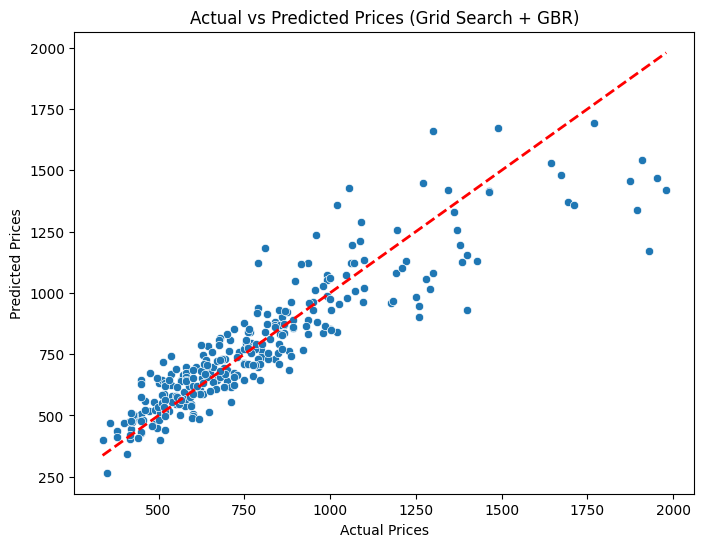

In [17]:
# pipeline with preprocessing and selected model
#columns : (['city', 'postal_code', 'department_code', 'lat', 'lon', 'surface', 'rooms', 'bedrooms', 'bathrooms', 'showers', 'floor', 'balconies', 'terraces', 'parking_places', 'cellars', 'elevator', 'disabled_access', 'furnished', 'duplex', 'energy_class', 'energy_value', 'ghg_class', 'ghg_value', 'energy_min_cost', 'energy_max_cost', 'heating_type', 'new_property', 'description'], ['price'])
numerical_features = ["lat", "lon", "surface", "rooms", "bedrooms", "bathrooms", "showers", "floor", "balconies", "terraces", "parking_places", "cellars", "energy_value", "ghg_value", "energy_min_cost", "energy_max_cost"]
categorical_features = ["city", "postal_code", "department_code", "elevator", "disabled_access", "furnished", "duplex", "energy_class", "ghg_class", "heating_type",  "new_property"]
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])
# pipeline with free hyper parameters for grid-search
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', GradientBoostingRegressor())
])
from sklearn.model_selection import GridSearchCV
param_grid = {
    'regressor__n_estimators': [100, 200, 300, 500, 800],
    'regressor__learning_rate': [0.05, 0.1, 0.2, 0.5],
    'regressor__max_depth': [3, 5, 7, 10]
}
grid_search = GridSearchCV(pipeline, param_grid, cv=5, n_jobs=-1, scoring='r2')

X = df[pertinent_features]
y = df["price"]
X_train_all, X_test_all, y_train_all, y_test_all = train_test_split(X, y, test_size=0.2, random_state=42)

grid_search.fit(X_train_all, y_train_all)
print(f"Best parameters: {grid_search.best_params_}")
best_model = grid_search.best_estimator_
y_pred_grid = best_model.predict(X_test_all)
mse_grid = mean_squared_error(y_test_all, y_pred_grid)
r2_grid = r2_score(y_test_all, y_pred_grid)
print(f"Grid Search + GBR - Mean Squared Error: {mse_grid}")
print(f"Grid Search + GBR - R² Score: {r2_grid}")
# Plot predicted vs actual prices for Grid Search model
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test_all, y=y_pred_grid)
plt.plot([y_test_all.min(), y_test_all.max()], [y_test_all.min(),
            y_test_all.max()], '--', lw=2, color='red')
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Prices (Grid Search + GBR)")
plt.show()

In [18]:
best_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformer

### Importance des features

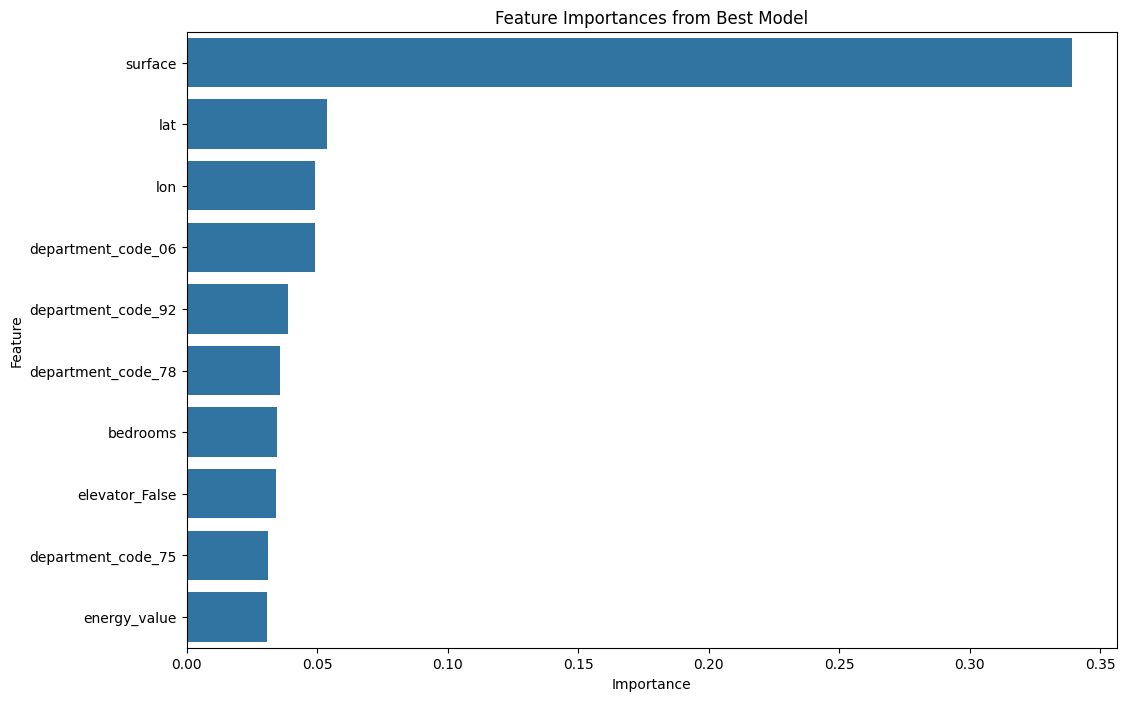

In [19]:
feature_names = numerical_features + list(best_model.named_steps['preprocessor'].transformers_[1][1].get_feature_names_out(categorical_features))
importances = best_model.named_steps['regressor'].feature_importances_
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)
# head 10 features
f = feature_importance_df.head(10)
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=f)
plt.title('Feature Importances from Best Model')
plt.show()

In [20]:
numerical_features = ["lat", "lon", "surface", "rooms", "bedrooms", "bathrooms", "showers", "floor", "balconies", "terraces", "parking_places", "cellars", "energy_value", "ghg_value", "energy_min_cost", "energy_max_cost"]
categorical_features = ["city", "postal_code", "department_code", "elevator", "disabled_access", "furnished", "duplex", "energy_class", "ghg_class", "heating_type",  "new_property"]

### Ajout d'une itération PCA normalisée 
Utilisation de toutes les feature "réelles", on applique la PCA dessus pour obtenir 10 features abstraites (réduction de dimensions).  
On applique la PCA dessus.

Best parameters: {'preprocessor__num__pca__n_components': 5, 'regressor__learning_rate': 0.2, 'regressor__max_depth': 3, 'regressor__n_estimators': 500}
Grid Search + GBR - Mean Squared Error: 21839.401714023927
Grid Search + GBR - R² Score: 0.788331164971459


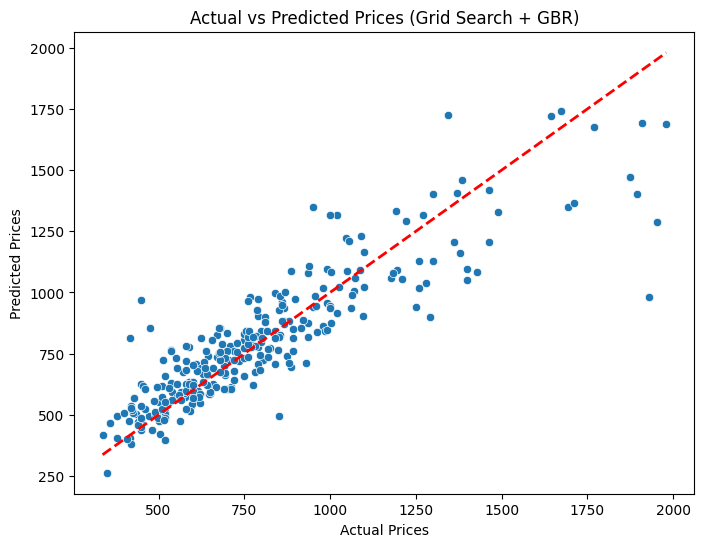

In [21]:
#columns : (['city', 'postal_code', 'department_code', 'lat', 'lon', 'surface', 'rooms', 'bedrooms', 'bathrooms', 'showers', 'floor', 'balconies', 'terraces', 'parking_places', 'cellars', 'elevator', 'disabled_access', 'furnished', 'duplex', 'energy_class', 'energy_value', 'ghg_class', 'ghg_value', 'energy_min_cost', 'energy_max_cost', 'heating_type', 'new_property', 'description'], ['price'])
numerical_features = ["lat", "lon", "surface", "rooms", "bedrooms", "bathrooms", "showers", "floor", "balconies", "terraces", "parking_places", "cellars", "energy_value", "ghg_value", "energy_min_cost", "energy_max_cost"]
categorical_features = ["city", "postal_code", "department_code", "elevator", "disabled_access", "furnished", "duplex", "energy_class", "ghg_class", "heating_type",  "new_property"]
numeric_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA())
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, numerical_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])

# pipeline with free hyper parameters for grid-search
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', GradientBoostingRegressor())
])
from sklearn.model_selection import GridSearchCV
param_grid = {
    'preprocessor__num__pca__n_components': [5, 10, 15],
    'regressor__n_estimators': [100, 200, 300, 500],
    'regressor__learning_rate': [0.05, 0.1, 0.2, 0.5],
    'regressor__max_depth': [3, 5, 7, 10]
}
grid_search = GridSearchCV(pipeline, param_grid, cv=5, n_jobs=-1, scoring='r2')

X = df[pertinent_features]
y = df["price"]
X_train_all, X_test_all, y_train_all, y_test_all = train_test_split(X, y, test_size=0.2, random_state=42)

grid_search.fit(X_train_all, y_train_all)
print(f"Best parameters: {grid_search.best_params_}") ; best_model = grid_search.best_estimator_
y_pred_grid = best_model.predict(X_test_all) ; mse_grid = mean_squared_error(y_test_all, y_pred_grid) ; r2_grid = r2_score(y_test_all, y_pred_grid)
print(f"Grid Search + GBR - Mean Squared Error: {mse_grid}") ; print(f"Grid Search + GBR - R² Score: {r2_grid}")
# Plot predicted vs actual prices for Grid Search model
plt.figure(figsize=(8, 6)) ; sns.scatterplot(x=y_test_all, y=y_pred_grid) ; plt.plot([y_test_all.min(), y_test_all.max()], [y_test_all.min(),y_test_all.max()], '--', lw=2, color='red')
plt.xlabel("Actual Prices") ; plt.ylabel("Predicted Prices") ; plt.title("Actual vs Predicted Prices (Grid Search + GBR)") ; plt.show()

## Les conclusions sont que la PCA n'est pas idéale pour de telles données.
## On peut essayer de rajouter des features, d'utiliser des modèles plus adapté à un mix categories/réel

best_model

### Ajout de nouvelles features (étape de la pipeline)
Une alternative à Longitude/Latitude sont la distance à la plus grande ville, le logarithme de la population de la ville la plus proche ainsi que le rang de la ville la plus proche. (trouvables dans features_maker.py)  
Cela fait suite à notre constat ci-dessus du manque d'influence et d'expressivité de la latitude et de la longitude sur le montant du loyer en tant que données brutes lors de l'entrainement des modèles.

(1161, 27) (291, 27) (1161,) (291,)
Best parameters: {'preprocessor__geo__geo_features__top_n': 10, 'regressor__learning_rate': 0.1, 'regressor__max_depth': 3, 'regressor__n_estimators': 800}
Grid Search + GBR + NearestCity - Mean Squared Error: 16980.87985762737
Grid Search + GBR + NearestCity - R² Score: 0.8354202599370866


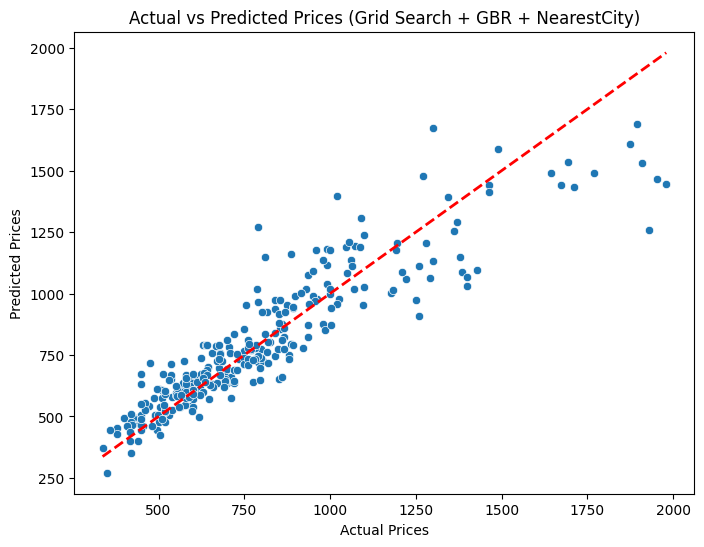

In [22]:
geo_features = ["lat", "lon"]

geo_pipeline = Pipeline([
    ("geo_features", NearestCityTransformer())
])

preprocessor = ColumnTransformer([
    ('geo', geo_pipeline, geo_features),
    ('num', "passthrough", [f for f in numerical_features if f not in geo_features]),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])

param_grid = {
    "preprocessor__geo__geo_features__top_n": [5, 10, 20, 50],
    "regressor__n_estimators": [200, 500, 800],
    "regressor__learning_rate": [0.05, 0.1],
    "regressor__max_depth": [3, 5, 7]
}

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', GradientBoostingRegressor())
])
grid_search = GridSearchCV(pipeline, param_grid, cv=5, n_jobs=-1, scoring='r2')
X = df[numerical_features + categorical_features]
y = df["price"]
X_train_all, X_test_all, y_train_all, y_test_all = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train_all.shape, X_test_all.shape, y_train_all.shape, y_test_all.shape)

grid_search.fit(X_train_all, y_train_all)
print(f"Best parameters: {grid_search.best_params_}")
best_model = grid_search.best_estimator_
y_pred_grid = best_model.predict(X_test_all)
mse_grid = mean_squared_error(y_test_all, y_pred_grid)
r2_grid = r2_score(y_test_all, y_pred_grid)
print(f"Grid Search + GBR + NearestCity - Mean Squared Error: {mse_grid}")
print(f"Grid Search + GBR + NearestCity - R² Score: {r2_grid}")
# Plot predicted vs actual prices for Grid Search model
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test_all, y=y_pred_grid)
plt.plot([y_test_all.min(), y_test_all.max()], [y_test_all.min(),
            y_test_all.max()], '--', lw=2, color='red')
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Prices (Grid Search + GBR + NearestCity)")
plt.show()

### Importance des features
On se rend compte que ces nouvelles features ont une influence considérables !

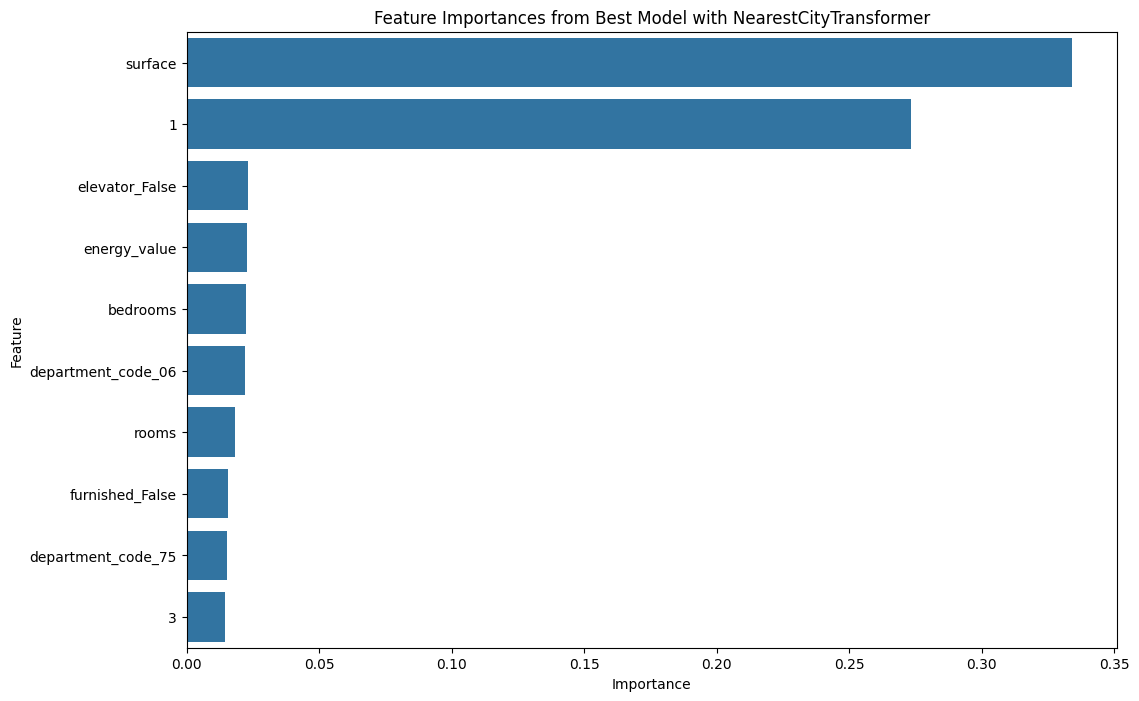

In [23]:
# Importance des features
feature_names = (list(["1", "2", "3"]) +
                 [f for f in numerical_features if f not in geo_features] +
                 list(best_model.named_steps['preprocessor'].transformers_[2][1].get_feature_names_out(categorical_features)))
importances = best_model.named_steps['regressor'].feature_importances_
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)
# head 10 features
f = feature_importance_df.head(10)
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=f)
plt.title('Feature Importances from Best Model with NearestCityTransformer')
plt.show()


In [24]:
best_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('geo', ...), ('num', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transf

### Conclusion

Le projet a réussi à construire un pipeline fonctionnelle de prédiction immobilière, avec une collecte de données réelles (2 000+ annonces via l’API Bien’ici), un prétraitement adapté (gestion des NaN, sélection de 28 features pertinentes), et une modélisation réfléchie (comparaison de 7 algorithmes, optimisation par GridSearchCV, métriques MSE/R²). 

Limites identifiées : 
Données : 1500 lignes léger pour un projet pareil.
Features : OneHotEncoding peu scalable, texte des descriptions non exploité.

Améliorations prioritaires :
Élargir les données : Intégrer SeLoger, Leboncoin, et des données macro-économiques (INSEE, OpenStreetMap). 
Feature engineering : Ajouter des ratios (prix/m²), des analyses de texte (TF-IDF), et des données géolocalisées (transports, écoles). 
Modélisation : Tester d’autres modèles

Résultats actuels : Les modèles comme Gradient Boosting et Random Forest offrent un bon compromis, tandis que la régression linéaire et KNN sont moins adaptés. Le R² (~0.7-0.8) est encourageant pour un prototype, mais nécessite une montée en échelle (20 000+ annonces, couverture nationale).